# Worksheet 7 -- Neural Networks-I

## Task 1 & 2

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

import tensorflow as tf

I0000 00:00:1779555607.762267  361375 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779555607.797246  361375 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779555608.644360  361375 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
spectra = np.load("spectrums.npy")
print("Spectra array shape:", spectra.shape)

Spectra array shape: (41423, 52, 4)


In [3]:
wave_grid = spectra[:, :, 0]
spectrum = spectra[:, :, 1]
uncertainty = spectra[:, :, 2]
bin_width = spectra[:, :, 3]

In [4]:
# Is the same for each spectrum.
wg = wave_grid[0]
len(spectrum)

41423

In [5]:
print(f"Transit depth range: {spectrum.min():.1f} to {spectrum.max():.1f} ppm")
print(f"Mean uncertainty: {uncertainty.mean()} ppm")

Transit depth range: 0.0 to 0.1 ppm
Mean uncertainty: 7.327406919564325e-05 ppm


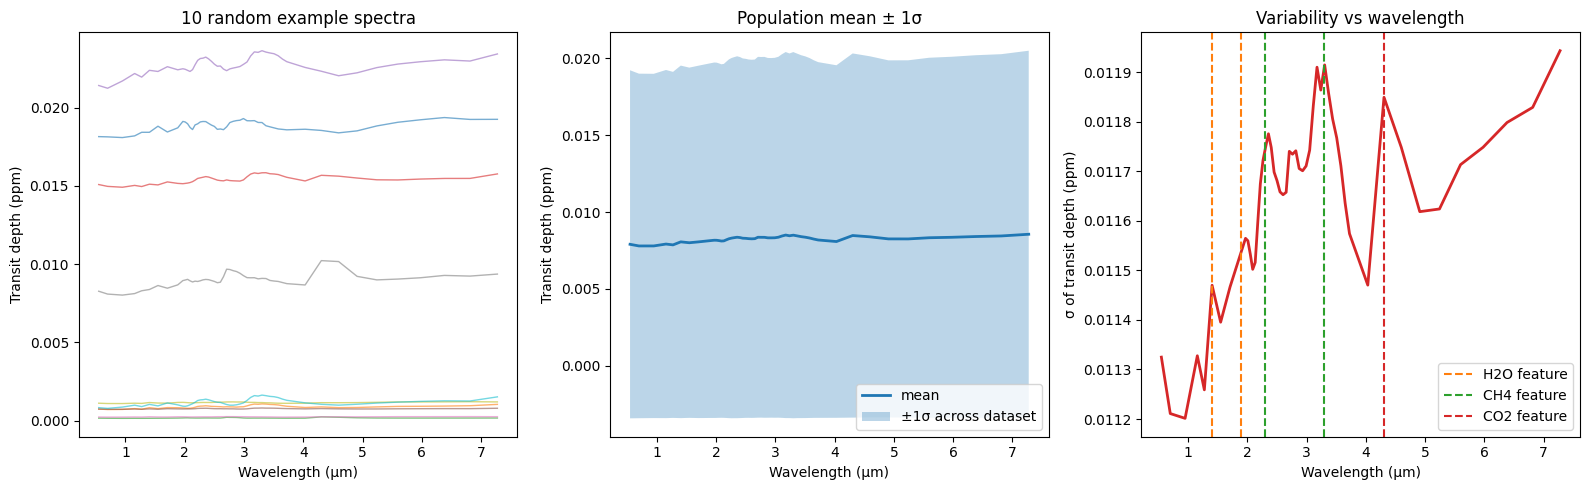

In [6]:
# Randomly chosen spectra
spec_idx = [100, 567, 10777, 23456, 37076, 40235, 19283, 856, 7451, 8254]
lines_info = {
    "H2O": {"wavelengths": [1.4, 1.9], "color": "C1"},
    "CH4": {"wavelengths": [2.3, 3.3], "color": "C2"},
    "CO2": {"wavelengths": [4.3], "color": "C3"}
}

fig, ax = plt.subplots(1, 3, figsize=(16, 5))
for i in spec_idx:
    ax[0].plot(wg, spectrum[i], label=f"Spectrum {i}", alpha=0.6, lw=1)
ax[0].set_xlabel("Wavelength (µm)")
ax[0].set_ylabel("Transit depth (ppm)")
ax[0].set_title("10 random example spectra")

mean_spec = spectrum.mean(axis=0)
std_spec = spectrum.std(axis=0)
ax[1].plot(wg, mean_spec, color="C0", lw=2, label="mean")
ax[1].fill_between(wg, mean_spec - std_spec, mean_spec + std_spec, alpha=0.3, label="±1σ across dataset")
ax[1].set_xlabel("Wavelength (µm)")
ax[1].set_ylabel("Transit depth (ppm)")
ax[1].set_title("Population mean ± 1σ")
ax[1].legend()

ax[2].plot(wg, std_spec, color="C3", lw=2)
for compound, info in lines_info.items():
    for j, wavelength in enumerate(info["wavelengths"]):
        label = f"{compound} feature" if j == 0 else None
        ax[2].axvline(wavelength, color=info["color"], ls="--", label=label)
ax[2].set_xlabel("Wavelength (µm)")
ax[2].set_ylabel("σ of transit depth (ppm)")
ax[2].set_title("Variability vs wavelength")
ax[2].legend()


plt.tight_layout()

## Task 3

### Preprocessing

In [7]:
labels = pd.read_csv("FM_Parameter_Table.csv")
aux_df = pd.read_csv("AuxillaryTable.csv")
display(labels)

,Unnamed: 0,planet_ID,planet_radius,planet_temp,log_H2O,log_CO2,log_CO,log_CH4,log_NH3
0,0,train1,0.559620,863.394770,-8.865868,-6.700707,-5.557561,-8.957615,-3.097540
1,1,train2,1.118308,1201.700465,-4.510258,-8.228966,-3.565427,-7.807424,-3.633658
2,2,train3,0.400881,1556.096477,-7.225472,-6.931472,-3.081975,-8.567854,-5.378472
3,3,train4,0.345974,1268.624884,-7.461157,-5.853334,-3.044711,-5.149378,-3.815568
4,4,train5,0.733184,1707.323564,-4.140844,-7.460278,-3.181793,-5.996593,-4.535345
...,...,...,...,...,...,...,...,...,...
41418,41418,train41419,1.430950,1167.563319,-7.556565,-7.075889,-4.735715,-7.532563,-7.854443
41419,41419,train41420,0.277752,649.703932,-7.434332,-7.161510,-5.274940,-4.100312,-3.651804
41420,41420,train41421,0.136016,1445.371723,-5.525906,-5.079240,-4.945121,-5.787630,-8.015444
41421,41421,train41422,0.707851,653.284686,-4.616695,-8.782546,-3.767229,-3.221403,-8.427805


In [8]:
targets = ["planet_radius", "planet_temp", "log_H2O", "log_CO2", "log_CO", "log_CH4", "log_NH3"]
Y_all = labels[targets].values

In [9]:
aux = pd.DataFrame({
    "log_star_distance": np.log10(aux_df["star_distance"]),
    "log_star_mass":     np.log10(aux_df["star_mass_kg"]),
    "log_star_radius":   np.log10(aux_df["star_radius_m"]),
    "star_temperature":  aux_df["star_temperature"],
    "log_planet_mass":   np.log10(aux_df["planet_mass_kg"]),
    "log_orbital_period":np.log10(aux_df["planet_orbital_period"]),
    "log_planet_dist":   np.log10(aux_df["planet_distance"]),
    "log_surface_grav":  np.log10(aux_df["planet_surface_gravity"]),
}).values 

In [10]:
# Build two input matrices: one with spectrum only, one with spectrum + auxiliary features.
X_spec = spectrum
X_full = np.concatenate([spectrum, aux], axis=1)

In [11]:
# Use identical splits (same random_state) so the two models see the same train/val/test rows.
Xs_left, Xs_test, Y_left, Y_test = train_test_split(X_spec, Y_all, test_size=0.1, random_state=42)
Xs_train, Xs_val, Y_train, Y_val = train_test_split(Xs_left, Y_left, test_size=0.111, random_state=42)

Xf_left, Xf_test, _, _ = train_test_split(X_full, Y_all, test_size=0.1, random_state=42)
Xf_train, Xf_val, _, _ = train_test_split(Xf_left, Y_left, test_size=0.111, random_state=42)

In [12]:
print(f"Spectrum-only  -> Train: {Xs_train.shape}, Val: {Xs_val.shape}, Test: {Xs_test.shape}")
print(f"Spectrum + aux -> Train: {Xf_train.shape}, Val: {Xf_val.shape}, Test: {Xf_test.shape}")

Spectrum-only  -> Train: (33141, 52), Val: (4139, 52), Test: (4143, 52)
Spectrum + aux -> Train: (33141, 60), Val: (4139, 60), Test: (4143, 60)


In [13]:
# Fit separate input scalers (different feature counts); a single target scaler since Y is the same.
Xs_scaler = StandardScaler().fit(Xs_train)
Xs_train_s = Xs_scaler.transform(Xs_train)
Xs_val_s = Xs_scaler.transform(Xs_val)
Xs_test_s = Xs_scaler.transform(Xs_test)

Xf_scaler = StandardScaler().fit(Xf_train)
Xf_train_s = Xf_scaler.transform(Xf_train)
Xf_val_s = Xf_scaler.transform(Xf_val)
Xf_test_s = Xf_scaler.transform(Xf_test)

Y_scaler = StandardScaler().fit(Y_train)
Y_train_s = Y_scaler.transform(Y_train)
Y_val_s = Y_scaler.transform(Y_val)
Y_test_s = Y_scaler.transform(Y_test)

### Building the Model

In [14]:
# Identical architecture for both models so any difference reflects the inputs, not the network.
def build_model(n_inputs, n_outputs):
    m = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(n_inputs,)),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(n_outputs, activation="linear"),
    ])
    m.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss="mse", metrics=["mae"])
    return m

# Set a fresh seed so the two models start from comparable initialisations.
tf.keras.utils.set_random_seed(42)
model_spec = build_model(Xs_train_s.shape[1], Y_train_s.shape[1])
tf.keras.utils.set_random_seed(42)
model_full = build_model(Xf_train_s.shape[1], Y_train_s.shape[1])

model_spec.summary()
model_full.summary()

E0000 00:00:1779555609.365509  361375 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         6,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,495 (60.53 KB)

 Trainable params: 15,495 (60.53 KB)

...

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         7,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,519 (64.53 KB)

 Trainable params: 16,519 (64.53 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Factory so each model gets its own callback instances (EarlyStopping holds internal state).
def make_callbacks():
    return [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6),
    ]

In [16]:
# Train both models with identical hyperparameters.
print("Training spectrum-only model...")
history_spec = model_spec.fit(
    Xs_train_s, Y_train_s,
    validation_data=(Xs_val_s, Y_val_s),
    epochs=300, batch_size=128, callbacks=make_callbacks(), verbose=2,
)

print("\nTraining spectrum + aux model...")
history_full = model_full.fit(
    Xf_train_s, Y_train_s,
    validation_data=(Xf_val_s, Y_val_s),
    epochs=300, batch_size=128, callbacks=make_callbacks(), verbose=2,
)

Training spectrum-only model...
Epoch 1/300
259/259 - 1s - 3ms/step - loss: 0.8711 - mae: 0.7666 - val_loss: 0.8208 - val_mae: 0.7425 - learning_rate: 0.0010
Epoch 2/300
259/259 - 0s - 865us/step - loss: 0.7975 - mae: 0.7264 - val_loss: 0.7638 - val_mae: 0.7054 - learning_rate: 0.0010
Epoch 3/300
259/259 - 0s - 855us/step - loss: 0.7480 - mae: 0.6981 - val_loss: 0.7160 - val_mae: 0.6809 - learning_rate: 0.0010
Epoch 4/300
259/259 - 0s - 859us/step - loss: 0.7071 - mae: 0.6744 - val_loss: 0.6962 - val_mae: 0.6756 - learning_rate: 0.0010
Epoch 5/300
259/259 - 0s - 793us/step - loss: 0.6752 - mae: 0.6556 - val_loss: 0.7300 - val_mae: 0.6829 - learning_rate: 0.0010
Epoch 6/300
259/259 - 0s - 759us/step - loss: 0.6484 - mae: 0.6392 - val_loss: 0.7017 - val_mae: 0.6638 - learning_rate: 0.0010
Epoch 7/300
259/259 - 0s - 744us/step - loss: 0.6266 - mae: 0.6258 - val_loss: 0.6419 - val_mae: 0.6317 - learning_rate: 0.0010
Epoch 8/300
259/259 - 0s - 720us/step - loss: 0.6058 - mae: 0.6125 - val_l

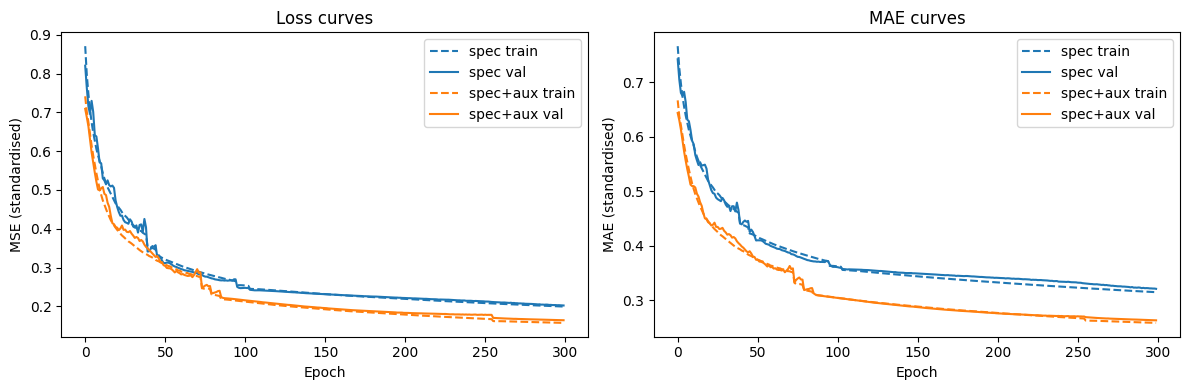

In [17]:
# Overlay loss/MAE curves of both models on the same axes for direct comparison.
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history_spec.history["loss"], label="spec train", color="C0", ls="--")
ax[0].plot(history_spec.history["val_loss"], label="spec val", color="C0")
ax[0].plot(history_full.history["loss"], label="spec+aux train", color="C1", ls="--")
ax[0].plot(history_full.history["val_loss"], label="spec+aux val", color="C1")
ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("MSE (standardised)"); ax[0].legend()
ax[0].set_title("Loss curves")

ax[1].plot(history_spec.history["mae"], label="spec train", color="C0", ls="--")
ax[1].plot(history_spec.history["val_mae"], label="spec val", color="C0")
ax[1].plot(history_full.history["mae"], label="spec+aux train", color="C1", ls="--")
ax[1].plot(history_full.history["val_mae"], label="spec+aux val", color="C1")
ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("MAE (standardised)"); ax[1].legend()
ax[1].set_title("MAE curves")
plt.tight_layout()
plt.show()

### Predict labels

In [18]:
# Predict on the test set with both models and invert the target scaling back to physical units.
y_pred_spec = Y_scaler.inverse_transform(model_spec.predict(Xs_test_s))
y_pred_full = Y_scaler.inverse_transform(model_full.predict(Xf_test_s))

# Per-target MAE and R^2 for both models, plus the improvement gained from the auxiliary features.
print(f"{'Label':<15} {'MAE_spec':>10} {'MAE_full':>10} {'ΔMAE':>10}  "
      f"{'R²_spec':>10} {'R²_full':>10} {'ΔR²':>10}")
for i, name in enumerate(targets):
    mae_s = mean_absolute_error(Y_test[:, i], y_pred_spec[:, i])
    mae_f = mean_absolute_error(Y_test[:, i], y_pred_full[:, i])
    r2_s = r2_score(Y_test[:, i], y_pred_spec[:, i])
    r2_f = r2_score(Y_test[:, i], y_pred_full[:, i])
    print(f"{name:<15} {mae_s:>10.4f} {mae_f:>10.4f} {mae_f - mae_s:>+10.4f}  "
          f"{r2_s:>10.4f} {r2_f:>10.4f} {r2_f - r2_s:>+10.4f}")

130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 477us/step
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 472us/step
Label             MAE_spec   MAE_full       ΔMAE     R²_spec    R²_full        ΔR²
planet_radius       0.1166     0.0184    -0.0982      0.8681     0.9955    +0.1274
planet_temp        98.6436    38.9272   -59.7164      0.8639     0.9841    +0.1202
log_H2O             0.5751     0.5686    -0.0064      0.8044     0.8032    -0.0012
log_CO2             0.3864     0.3794    -0.0070      0.8638     0.8638    +0.0000
log_CO              0.4733     0.4552    -0.0181      0.5162     0.5612    +0.0451
log_CH4             0.3492     0.3348    -0.0143      0.9175     0.9183    +0.0008
log_NH3             0.5606     0.5727    +0.0121      0.7477     0.7253    -0.0224


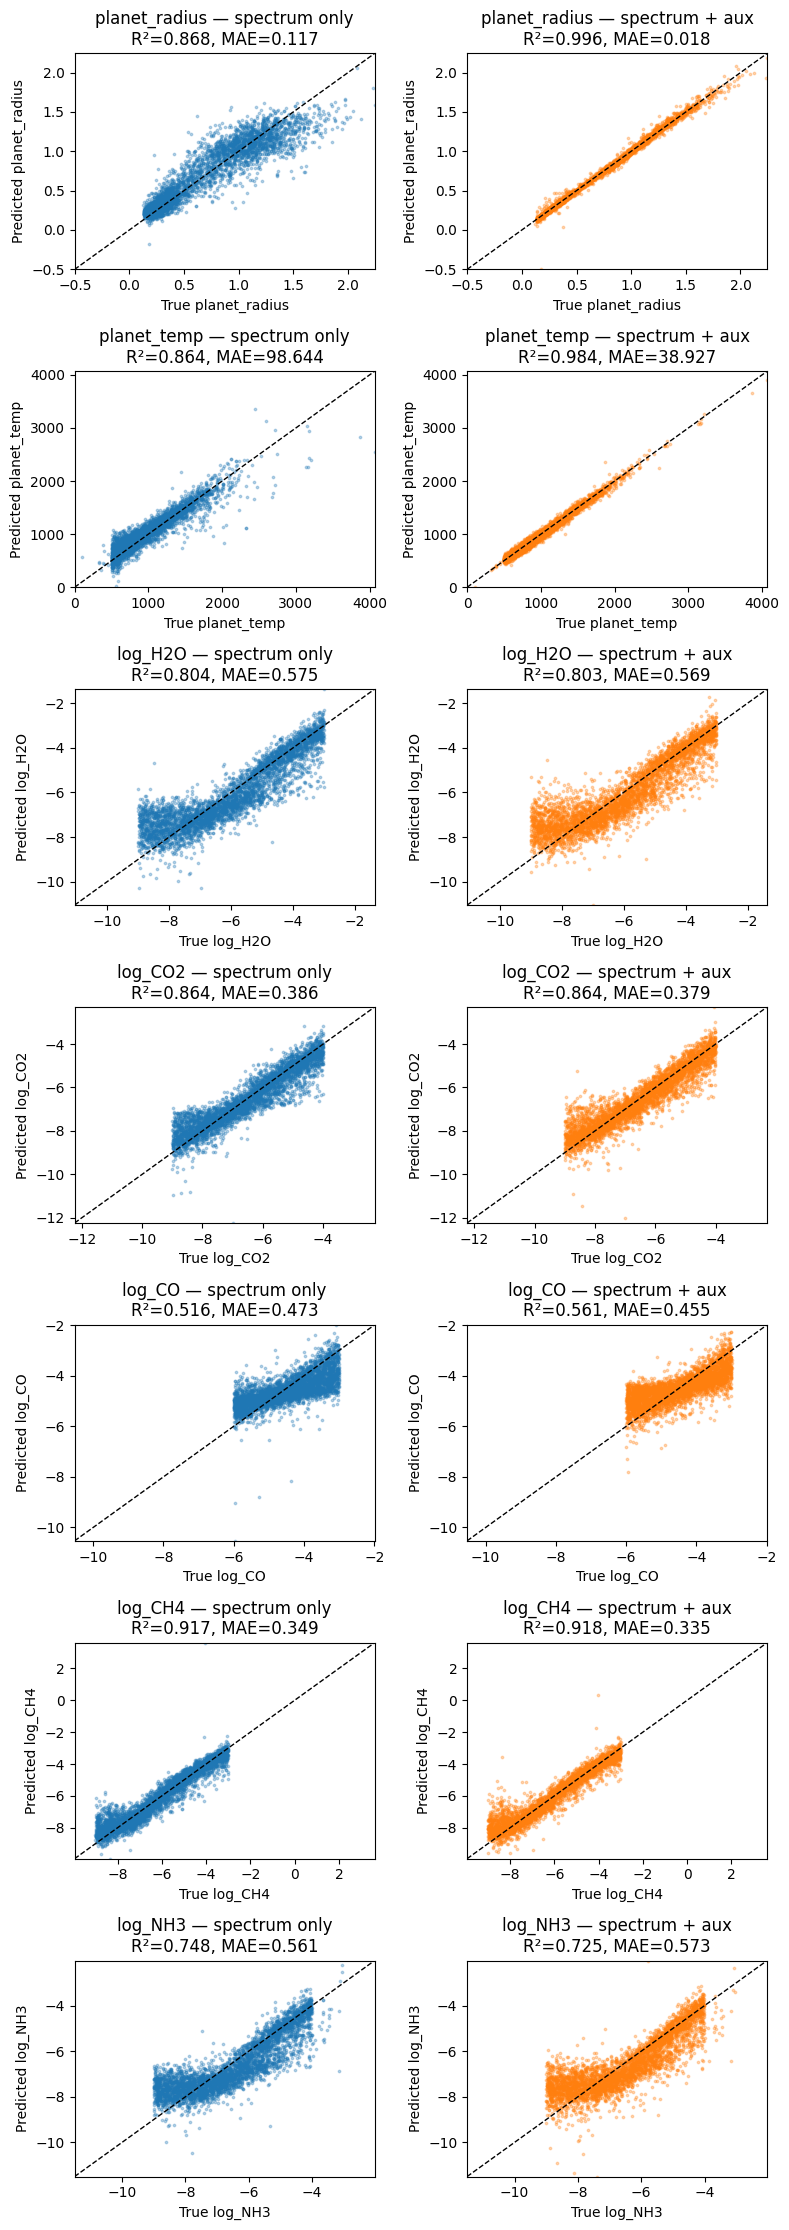

In [19]:
# One row per target: spectrum-only on the left, spectrum+aux on the right, shared axis limits.
n_targets = len(targets)
fig, axes = plt.subplots(n_targets, 2, figsize=(8, 3.2 * n_targets))

for i, name in enumerate(targets):
    # Shared limits so the two scatter plots are visually comparable.
    lims = [min(Y_test[:, i].min(), y_pred_spec[:, i].min(), y_pred_full[:, i].min()),
            max(Y_test[:, i].max(), y_pred_spec[:, i].max(), y_pred_full[:, i].max())]

    for j, (y_pred, tag, color) in enumerate(
        [(y_pred_spec, "spectrum only", "C0"), (y_pred_full, "spectrum + aux", "C1")]
    ):
        ax = axes[i, j]
        ax.scatter(Y_test[:, i], y_pred[:, i], s=3, alpha=0.3, color=color)
        ax.plot(lims, lims, "k--", lw=1)  # y = x reference line
        ax.set_xlim(lims); ax.set_ylim(lims)
        ax.set_xlabel(f"True {name}"); ax.set_ylabel(f"Predicted {name}")
        r2_i = r2_score(Y_test[:, i], y_pred[:, i])
        mae_i = mean_absolute_error(Y_test[:, i], y_pred[:, i])
        ax.set_title(f"{name} — {tag}\nR²={r2_i:.3f}, MAE={mae_i:.3f}")

plt.tight_layout()
plt.show()